In [1]:
from google.colab import drive
drive.mount('/content/drive')

ModuleNotFoundError: No module named 'google.colab'

In [ ]:
!pip install ultralytics

In [7]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.6/383.6 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.6/233.6 kB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.5/78.5 kB 7.5 MB/s eta 0:00:00


In [8]:
from ultralytics import YOLO
from PIL import Image
import matplotlib.pyplot as plt
import os
import cv2
import optuna

# yolo8s

In [4]:
# Transfer from other model
model_yolo8s = YOLO('/content/drive/MyDrive/extract_vietnam/yolov8s.pt')
print(model_yolo8s.info())
#plot_model(model, to_file='vgg.png')

YOLOv8s summary: 129 layers, 11,166,560 parameters, 0 gradients, 28.8 GFLOPs
(129, 11166560, 0, 28.816844800000002)


In [2]:
import optuna
from ultralytics import YOLO

def objective(trial):
    # กำหนดช่วงค่าที่ต้องการค้นหา
    epochs = trial.suggest_int("epochs", 10, 50)
    batch_size = trial.suggest_int("batch_size", 8, 32)
    learning_rate = trial.suggest_loguniform("lr0", 1e-4, 1e-2)
    optimizer = trial.suggest_categorical("optimizer", ["SGD", "Adam", "AdamW"])

    # โหลดโมเดล YOLO
    model = YOLO('yolov8s.pt')

    # เริ่มการฝึก
    results = model.train(
        data='/content/drive/MyDrive/extract_vietnam/data_detectTOEIC.yaml',
        epochs=epochs,
        batch=batch_size,
        imgsz=640,
        optimizer=optimizer,
        lr0=learning_rate,

    )

    # คืนค่า metric (เช่น mAP) ที่ได้จากการฝึก
    # The 'results' object likely has 'box' as an attribute now, and 'map50' is within it.
    return results.box.map50  # Access map50 directly through results.box.map50

# เริ่มกระบวนการค้นหาค่าที่ดีที่สุด
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=5)  # ค้นหา 10 รอบ

# แสดงค่าพารามิเตอร์ที่ดีที่สุด
print("Best hyperparameters:", study.best_params)

[I 2025-02-20 16:29:24,083] A new study created in memory with name: no-name-fe982633-460a-46b2-a86f-395ae4bfcd57


Ultralytics 8.3.78 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=detect, mode=train, model=yolov8s.pt, data=/content/drive/MyDrive/extract_vietnam/data_detectTOEIC.yaml, epochs=46, time=None, patience=100, batch=22, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train4, exist_ok=False, pretrained=True, optimizer=SGD, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_label

train: Scanning /content/drive/MyDrive/extract_vietnam/Detect_Toeic/labels/train.cache... 70 images, 0 backgrounds, 0 corrupt: 100%|██████████| 70/70 [00:00<?, ?it/s]

albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, num_output_channels=3, method='weighted_average'), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))



val: Scanning /content/drive/MyDrive/extract_vietnam/Detect_Toeic/labels/val.cache... 15 images, 0 backgrounds, 0 corrupt: 100%|██████████| 15/15 [00:00<?, ?it/s]


...


17 epochs completed in 0.017 hours.
Optimizer stripped from runs/detect/train8/weights/last.pt, 22.5MB
Optimizer stripped from runs/detect/train8/weights/best.pt, 22.5MB

Validating runs/detect/train8/weights/best.pt...
Ultralytics 8.3.78 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:00<00:00,  5.73it/s]


                   all         15         15          1      0.909      0.956      0.436
Speed: 0.2ms preprocess, 5.5ms inference, 0.0ms loss, 1.0ms postprocess per image
Results saved to runs/detect/train8


[I 2025-02-20 16:39:44,811] Trial 4 finished with value: 0.9564285714285714 and parameters: {'epochs': 17, 'batch_size': 24, 'lr0': 0.0001439035419097835, 'optimizer': 'Adam'}. Best is trial 2 with value: 0.995.


Best hyperparameters: {'epochs': 39, 'batch_size': 19, 'lr0': 0.0024195010860978052, 'optimizer': 'Adam'}


In [4]:
# สร้างโมเดลใหม่ด้วยพารามิเตอร์ที่ดีที่สุด
best_params = study.best_params

model = YOLO("yolov8s.pt")  # โหลดโมเดล YOLOv8s (pretrained)

# เทรนโมเดลด้วยพารามิเตอร์ที่ดีที่สุด
results = model.train(
    data='/content/drive/MyDrive/extract_vietnam/data_detectTOEIC.yaml',
    epochs=best_params["epochs"],
    batch=best_params["batch_size"],
    imgsz=640,
    optimizer=best_params["optimizer"],
    lr0=best_params["lr0"],
)

# บันทึกโมเดลที่เทรนแล้ว
model.save("/content/drive/MyDrive/Project/train_model/yolo8s_trained.pt")  # เปลี่ยนเส้นทางตามที่ต้องการ

Ultralytics 8.3.78 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=detect, mode=train, model=yolov8s.pt, data=/content/drive/MyDrive/extract_vietnam/data_detectTOEIC.yaml, epochs=39, time=None, patience=100, batch=19, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train9, exist_ok=False, pretrained=True, optimizer=Adam, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labe

train: Scanning /content/drive/MyDrive/extract_vietnam/Detect_Toeic/labels/train.cache... 70 images, 0 backgrounds, 0 corrupt: 100%|██████████| 70/70 [00:00<?, ?it/s]

albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, num_output_channels=3, method='weighted_average'), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))



val: Scanning /content/drive/MyDrive/extract_vietnam/Detect_Toeic/labels/val.cache... 15 images, 0 backgrounds, 0 corrupt: 100%|██████████| 15/15 [00:00<?, ?it/s]


Plotting labels to runs/detect/train9/labels.jpg... 
optimizer: Adam(lr=0.0024195010860978052, momentum=0.937) with parameter groups 57 weight(decay=0.0), 64 weight(decay=0.00044531249999999996), 63 bias(decay=0.0)
TensorBoard: model graph visualization added ✅
Image sizes 640 train, 640 val
Using 2 dataloader workers
Logging results to runs/detect/train9
Starting training for 39 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


...

      39/39      4.48G     0.5027     0.3479     0.9396         50        640: 100%|██████████| 4/4 [00:01<00:00,  2.98it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:00<00:00,  3.42it/s]

                   all         15         15      0.996          1      0.995      0.893



39 epochs completed in 0.034 hours.
Optimizer stripped from runs/detect/train9/weights/last.pt, 22.5MB
Optimizer stripped from runs/detect/train9/weights/best.pt, 22.5MB

Validating runs/detect/train9/weights/best.pt...
Ultralytics 8.3.78 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:00<00:00,  6.36it/s]


                   all         15         15      0.993          1      0.995      0.921
Speed: 0.2ms preprocess, 5.2ms inference, 0.0ms loss, 0.9ms postprocess per image
Results saved to runs/detect/train9


In [ ]:
# โหลดโมเดลที่เซฟไว้
model = YOLO("/path/to/best_model.pt")

# ใช้โมเดลในการตรวจจับวัตถุ
results = model.predict(source="/path/to/test_images", save=True)

In [ ]:
metrics = model_yolo8s.val()

# yolo8n

In [5]:
import optuna
from ultralytics import YOLO

def objective(trial):
    # กำหนดช่วงค่าที่ต้องการค้นหา
    epochs = trial.suggest_int("epochs", 10, 50)
    batch_size = trial.suggest_int("batch_size", 8, 32)
    learning_rate = trial.suggest_loguniform("lr0", 1e-4, 1e-2)
    optimizer = trial.suggest_categorical("optimizer", ["SGD", "Adam", "AdamW"])

    # โหลดโมเดล YOLO
    model = YOLO('/content/drive/MyDrive/extract_vietnam/yolov8n.pt')

    # เริ่มการฝึก
    results = model.train(
        data='/content/drive/MyDrive/extract_vietnam/data_detectTOEIC.yaml',
        epochs=epochs,
        batch=batch_size,
        imgsz=640,
        optimizer=optimizer,
        lr0=learning_rate,

    )

    # คืนค่า metric (เช่น mAP) ที่ได้จากการฝึก
    # The 'results' object likely has 'box' as an attribute now, and 'map50' is within it.
    return results.box.map50  # Access map50 directly through results.box.map50

# เริ่มกระบวนการค้นหาค่าที่ดีที่สุด
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=5)  # ค้นหา 5 รอบ

# แสดงค่าพารามิเตอร์ที่ดีที่สุด
print("Best hyperparameters:", study.best_params)

[I 2025-02-20 16:49:17,940] A new study created in memory with name: no-name-e2b59471-69bb-4df5-ad17-e15cdb732385


Ultralytics 8.3.78 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=detect, mode=train, model=/content/drive/MyDrive/extract_vietnam/yolov8n.pt, data=/content/drive/MyDrive/extract_vietnam/data_detectTOEIC.yaml, epochs=25, time=None, patience=100, batch=22, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train10, exist_ok=False, pretrained=True, optimizer=SGD, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save

train: Scanning /content/drive/MyDrive/extract_vietnam/Detect_Toeic/labels/train.cache... 70 images, 0 backgrounds, 0 corrupt: 100%|██████████| 70/70 [00:00<?, ?it/s]

albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, num_output_channels=3, method='weighted_average'), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))



val: Scanning /content/drive/MyDrive/extract_vietnam/Detect_Toeic/labels/val.cache... 15 images, 0 backgrounds, 0 corrupt: 100%|██████████| 15/15 [00:00<?, ?it/s]


...


46 epochs completed in 0.044 hours.
Optimizer stripped from runs/detect/train14/weights/last.pt, 6.2MB
Optimizer stripped from runs/detect/train14/weights/best.pt, 6.2MB

Validating runs/detect/train14/weights/best.pt...
Ultralytics 8.3.78 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:00<00:00,  6.78it/s]


                   all         15         15      0.996          1      0.995      0.949
Speed: 0.2ms preprocess, 3.3ms inference, 0.0ms loss, 1.6ms postprocess per image
Results saved to runs/detect/train14


[I 2025-02-20 16:58:41,799] Trial 4 finished with value: 0.995 and parameters: {'epochs': 46, 'batch_size': 8, 'lr0': 0.0007762074264002187, 'optimizer': 'Adam'}. Best is trial 2 with value: 0.995.


Best hyperparameters: {'epochs': 25, 'batch_size': 20, 'lr0': 0.001892222176144351, 'optimizer': 'AdamW'}


In [6]:
# สร้างโมเดลใหม่ด้วยพารามิเตอร์ที่ดีที่สุด
best_params = study.best_params

model = YOLO("/content/drive/MyDrive/extract_vietnam/yolov8n.pt")  # โหลดโมเดล YOLOv8s (pretrained)

# เทรนโมเดลด้วยพารามิเตอร์ที่ดีที่สุด
results = model.train(
    data='/content/drive/MyDrive/extract_vietnam/data_detectTOEIC.yaml',
    epochs=best_params["epochs"],
    batch=best_params["batch_size"],
    imgsz=640,
    optimizer=best_params["optimizer"],
    lr0=best_params["lr0"],
)

# บันทึกโมเดลที่เทรนแล้ว
model.save("/content/drive/MyDrive/Project/train_model/yolo8n_trained.pt")  # เปลี่ยนเส้นทางตามที่ต้องการ

Ultralytics 8.3.78 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=detect, mode=train, model=/content/drive/MyDrive/extract_vietnam/yolov8n.pt, data=/content/drive/MyDrive/extract_vietnam/data_detectTOEIC.yaml, epochs=25, time=None, patience=100, batch=20, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train15, exist_ok=False, pretrained=True, optimizer=AdamW, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, sa

train: Scanning /content/drive/MyDrive/extract_vietnam/Detect_Toeic/labels/train.cache... 70 images, 0 backgrounds, 0 corrupt: 100%|██████████| 70/70 [00:00<?, ?it/s]

albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, num_output_channels=3, method='weighted_average'), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))



val: Scanning /content/drive/MyDrive/extract_vietnam/Detect_Toeic/labels/val.cache... 15 images, 0 backgrounds, 0 corrupt: 100%|██████████| 15/15 [00:00<?, ?it/s]


Plotting labels to runs/detect/train15/labels.jpg... 
optimizer: AdamW(lr=0.001892222176144351, momentum=0.937) with parameter groups 57 weight(decay=0.0), 64 weight(decay=0.00046875), 63 bias(decay=0.0)
TensorBoard: model graph visualization added ✅
Image sizes 640 train, 640 val
Using 2 dataloader workers
Logging results to runs/detect/train15
Starting training for 25 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


...

      25/25      2.74G     0.6362      0.529     0.9818         49        640: 100%|██████████| 4/4 [00:00<00:00,  4.15it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:00<00:00,  7.18it/s]

                   all         15         15      0.996          1      0.995      0.909



25 epochs completed in 0.021 hours.
Optimizer stripped from runs/detect/train15/weights/last.pt, 6.2MB
Optimizer stripped from runs/detect/train15/weights/best.pt, 6.2MB

Validating runs/detect/train15/weights/best.pt...
Ultralytics 8.3.78 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:00<00:00,  7.30it/s]


                   all         15         15      0.977          1      0.995      0.918
Speed: 0.2ms preprocess, 2.6ms inference, 0.0ms loss, 1.1ms postprocess per image
Results saved to runs/detect/train15


# yolo11n

In [7]:
import optuna
from ultralytics import YOLO

def objective(trial):
    # กำหนดช่วงค่าที่ต้องการค้นหา
    epochs = trial.suggest_int("epochs", 10, 50)
    batch_size = trial.suggest_int("batch_size", 8, 32)
    learning_rate = trial.suggest_loguniform("lr0", 1e-4, 1e-2)
    optimizer = trial.suggest_categorical("optimizer", ["SGD", "Adam", "AdamW"])

    # โหลดโมเดล YOLO
    model = YOLO('/content/drive/MyDrive/extract_vietnam/yolo11n.pt')

    # เริ่มการฝึก
    results = model.train(
        data='/content/drive/MyDrive/extract_vietnam/data_detectTOEIC.yaml',
        epochs=epochs,
        batch=batch_size,
        imgsz=640,
        optimizer=optimizer,
        lr0=learning_rate,

    )

    # คืนค่า metric (เช่น mAP) ที่ได้จากการฝึก
    # The 'results' object likely has 'box' as an attribute now, and 'map50' is within it.
    return results.box.map50  # Access map50 directly through results.box.map50

# เริ่มกระบวนการค้นหาค่าที่ดีที่สุด
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=5)  # ค้นหา 5 รอบ

# แสดงค่าพารามิเตอร์ที่ดีที่สุด
print("Best hyperparameters:", study.best_params)

[I 2025-02-20 17:00:13,664] A new study created in memory with name: no-name-c9c2c698-b4c7-4011-bbb0-892595320eee


Ultralytics 8.3.78 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=detect, mode=train, model=/content/drive/MyDrive/extract_vietnam/yolo11n.pt, data=/content/drive/MyDrive/extract_vietnam/data_detectTOEIC.yaml, epochs=47, time=None, patience=100, batch=24, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train16, exist_ok=False, pretrained=True, optimizer=AdamW, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, sa

train: Scanning /content/drive/MyDrive/extract_vietnam/Detect_Toeic/labels/train.cache... 70 images, 0 backgrounds, 0 corrupt: 100%|██████████| 70/70 [00:00<?, ?it/s]

albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, num_output_channels=3, method='weighted_average'), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))



val: Scanning /content/drive/MyDrive/extract_vietnam/Detect_Toeic/labels/val.cache... 15 images, 0 backgrounds, 0 corrupt: 100%|██████████| 15/15 [00:00<?, ?it/s]


...


25 epochs completed in 0.025 hours.
Optimizer stripped from runs/detect/train20/weights/last.pt, 5.5MB
Optimizer stripped from runs/detect/train20/weights/best.pt, 5.5MB

Validating runs/detect/train20/weights/best.pt...
Ultralytics 8.3.78 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLO11n summary (fused): 100 layers, 2,582,347 parameters, 0 gradients, 6.3 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:00<00:00,  4.80it/s]


                   all         15         15          1      0.997      0.995        0.9
Speed: 0.2ms preprocess, 3.5ms inference, 0.0ms loss, 1.6ms postprocess per image
Results saved to runs/detect/train20


[I 2025-02-20 17:09:53,554] Trial 4 finished with value: 0.995 and parameters: {'epochs': 25, 'batch_size': 15, 'lr0': 0.00019367784099315636, 'optimizer': 'AdamW'}. Best is trial 0 with value: 0.995.


Best hyperparameters: {'epochs': 47, 'batch_size': 24, 'lr0': 0.0009119444127889876, 'optimizer': 'AdamW'}


In [8]:
# สร้างโมเดลใหม่ด้วยพารามิเตอร์ที่ดีที่สุด
best_params = study.best_params

model = YOLO("/content/drive/MyDrive/extract_vietnam/yolo11n.pt")  # โหลดโมเดล YOLOv8s (pretrained)

# เทรนโมเดลด้วยพารามิเตอร์ที่ดีที่สุด
results = model.train(
    data='/content/drive/MyDrive/extract_vietnam/data_detectTOEIC.yaml',
    epochs=best_params["epochs"],
    batch=best_params["batch_size"],
    imgsz=640,
    optimizer=best_params["optimizer"],
    lr0=best_params["lr0"],
)

# บันทึกโมเดลที่เทรนแล้ว
model.save("/content/drive/MyDrive/Project/train_model/yolo11n_trained.pt")  # เปลี่ยนเส้นทางตามที่ต้องการ

Ultralytics 8.3.78 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=detect, mode=train, model=/content/drive/MyDrive/extract_vietnam/yolo11n.pt, data=/content/drive/MyDrive/extract_vietnam/data_detectTOEIC.yaml, epochs=47, time=None, patience=100, batch=24, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train21, exist_ok=False, pretrained=True, optimizer=AdamW, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, sa

train: Scanning /content/drive/MyDrive/extract_vietnam/Detect_Toeic/labels/train.cache... 70 images, 0 backgrounds, 0 corrupt: 100%|██████████| 70/70 [00:00<?, ?it/s]

albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, num_output_channels=3, method='weighted_average'), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))



val: Scanning /content/drive/MyDrive/extract_vietnam/Detect_Toeic/labels/val.cache... 15 images, 0 backgrounds, 0 corrupt: 100%|██████████| 15/15 [00:00<?, ?it/s]


Plotting labels to runs/detect/train21/labels.jpg... 
optimizer: AdamW(lr=0.0009119444127889876, momentum=0.937) with parameter groups 81 weight(decay=0.0), 88 weight(decay=0.0005625000000000001), 87 bias(decay=0.0)
TensorBoard: model graph visualization added ✅
Image sizes 640 train, 640 val
Using 2 dataloader workers
Logging results to runs/detect/train21
Starting training for 47 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


...


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


      47/47      3.56G     0.4773     0.4955     0.8927         80        640: 100%|██████████| 3/3 [00:00<00:00,  3.52it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:00<00:00,  5.93it/s]


                   all         15         15      0.996          1      0.995      0.908

47 epochs completed in 0.041 hours.
Optimizer stripped from runs/detect/train21/weights/last.pt, 5.5MB
Optimizer stripped from runs/detect/train21/weights/best.pt, 5.5MB

Validating runs/detect/train21/weights/best.pt...
Ultralytics 8.3.78 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLO11n summary (fused): 100 layers, 2,582,347 parameters, 0 gradients, 6.3 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:00<00:00,  7.06it/s]


                   all         15         15      0.995          1      0.995      0.934
Speed: 0.4ms preprocess, 2.8ms inference, 0.0ms loss, 1.2ms postprocess per image
Results saved to runs/detect/train21


--------------------------------------------------------------------------------

# ส่วนเกิน เดี๋ยวลบและ

In [4]:
!pip install keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 3.3 MB/s eta 0:00:00


In [16]:
# Multiple image
#import libraries
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import os
import keras_tuner
from keras_tuner.tuners import RandomSearch

# Data augmentation
from keras.preprocessing.image import load_img, img_to_array
from keras.applications.vgg16 import VGG16, preprocess_input, decode_predictions

# # load an image from file
# directory_path = '/content/drive/My Drive/archive/dataset/'
# folder_names = ["Surprise","Sad","Nautral","Happy","Angry","Ahegao"]
# image_test = directory_path + folder_names[0]+ "/cropped.png"  #bear_18.jpeg is white bear, bear_1.jpg is brown bear
# print(image_test)

# # Load the image and resize it to the required size of 224×224 pixels.
# image = load_img(image_test, target_size=(224, 224))  # target_size should be (224, 224)

# # Convert the image pixels to a numpy array
# image = img_to_array(image)

# # Reshape data for the model
# image = image.reshape((1, image.shape[0], image.shape[1], image.shape[2]))

# # Prepare the image for the VGG model
# image = preprocess_input(image)

# # Load the VGG16 model pre-trained on ImageNet
# model = VGG16()

# # Predict the probability across all output classes
# yhat = model.predict(image)

# # Convert the probabilities to class labels
# label = decode_predictions(yhat)
# # Retrieve the most likely result, e.g. highest probability
# label = label[0][0]
# # Print the classification
# print('%s (%.2f%%)' % (label[1], label[2]*100))

# Ensure the directory_path is correct
directory_path = '/content/drive/MyDrive/extract_vietnam/Dataset/images' # Corrected path if necessary

image_height=224
image_width=224
IMG_SIZE = (224, 224)
batch_size=16

# load images from file
ds_train=tf.keras.preprocessing.image_dataset_from_directory(
    directory_path, # Make sure 'train' folder exists at this location
    labels="inferred",
    label_mode="int",
    color_mode="rgb",
    batch_size=batch_size,
    image_size=(image_height,image_width),
    shuffle=True,
    seed=12,
    validation_split=.1,
    subset="training",

)

ds_validation=tf.keras.preprocessing.image_dataset_from_directory(
    directory_path, # Make sure 'val' folder exists at this location
    labels="inferred",
    label_mode="int",
    color_mode="rgb",
    batch_size=batch_size,
    image_size=(image_height,image_width),
    shuffle=True,
    seed=12,
    validation_split=.1,
    subset="validation"
)

Found 178 files belonging to 3 classes.
Using 161 files for training.
Found 178 files belonging to 3 classes.
Using 17 files for validation.


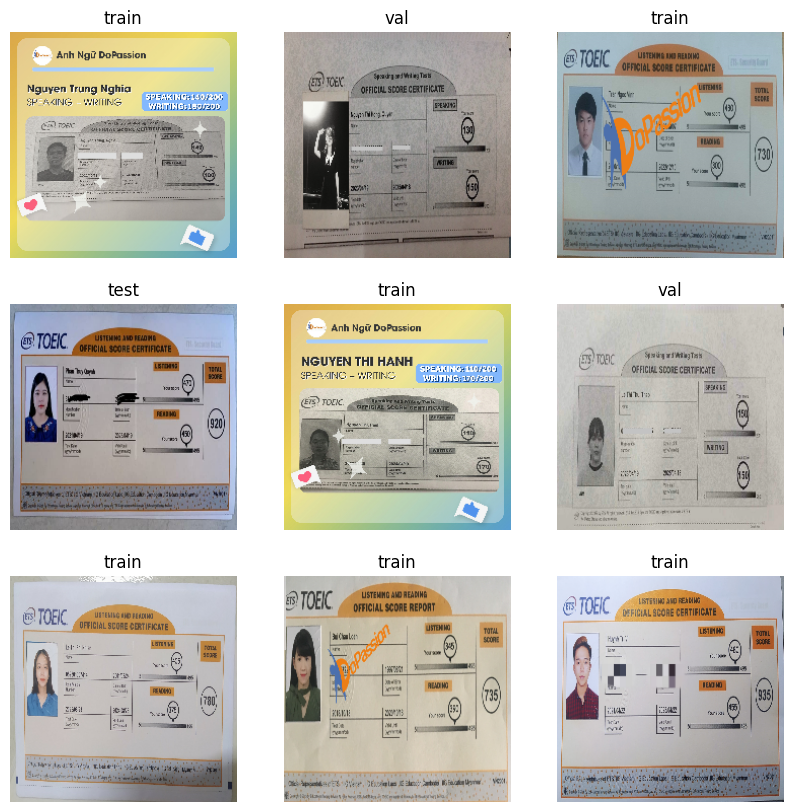

In [17]:
# Show the first nine images and labels from the training set:

class_names = ds_train.class_names

plt.figure(figsize=(10, 10))
for images, labels in ds_train.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

In [ ]:
# As the original dataset doesn't contain a test set, you will create one.
# To do so, determine how many batches of data are available in the validation set
# using tf.data.experimental.cardinality, then move 20% of them to a test set.
val_batches = tf.data.experimental.cardinality(ds_validation)
ds_test = ds_validation.take(val_batches // 5)
ds_validation = ds_validation.skip(val_batches // 5)

In [ ]:
print('Number of validation batches: %d' % tf.data.experimental.cardinality(ds_validation))
print('Number of test batches: %d' % tf.data.experimental.cardinality(ds_test))

Number of validation batches: 36
Number of test batches: 9


In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

ds_train = ds_train.prefetch(buffer_size=AUTOTUNE)
ds_validation = ds_validation.prefetch(buffer_size=AUTOTUNE)
ds_test = ds_test.prefetch(buffer_size=AUTOTUNE)

In [ ]:
# Rescale pixel values
preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input
rescale = tf.keras.layers.Rescaling(1./127.5, offset=-1)

In [ ]:
# Create the base model from the pre-trained model MobileNet V2
IMG_SHAPE = IMG_SIZE + (3,)
base_model = tf.keras.applications.MobileNetV2(input_shape=IMG_SHAPE,
                                               include_top=False,
                                               weights='imagenet')  # use imagenet that is pretrian weight and cut head layer so tnclude_top = false

In [ ]:
# This feature extractor converts each 160x160x3 image into a 5x5x1280 block
# of features. Let's see what it does to an example batch of images:

image_batch, label_batch = next(iter(ds_train))
feature_batch = base_model(image_batch)
print(feature_batch.shape)

(16, 7, 7, 1280)


In [ ]:
# Freeze the convolutional base
base_model.trainable = False # use pretrian weight

In [ ]:
# Let's take a look at the base model architecture
base_model.summary()

Model: "mobilenetv2_1.00_224"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv1 (Conv2D)                │ (None, 112, 112, 32)      │             864 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bn_Conv1 (BatchNormalization) │ (None, 112, 112, 32)      │             128 │ Conv1[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv1_relu (ReLU)             │ (None, 112, 112, 32)      │               0 │ bn_Conv1[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise       │ (None, 112, 112, 32)      │             288 │ Conv1_relu[0][0]           │
│ (DepthwiseConv2D)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise_BN    │ (None, 112, 112, 32)      │             128 │ expanded_conv_depthwise[0… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise_relu  │ (None, 112, 112, 32)      │               0 │ expanded_conv_depthwise_B… │
│ (ReLU)                        │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project         │ (None, 112, 112, 16)      │             512 │ expanded_conv_depthwise_r… │
│ (Conv2D)                      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project_BN      │ (None, 112, 112, 16)      │              64 │ expanded_conv_project[0][… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand (Conv2D)       │ (None, 112, 112, 96)      │           1,536 │ expanded_conv_project_BN[… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand_BN             │ (None, 112, 112, 96)      │             384 │ block_1_expand[0][0]       │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand_relu (ReLU)    │ (None, 112, 112, 96)      │               0 │ block_1_expand_BN[0][0]    │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_pad (ZeroPadding2D)   │ (None, 113, 113, 96)      │               0 │ block_1_expand_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_depthwise             │ (None, 56, 56, 96)        │             864 │ block_1_pad[0][0]          │
│ (DepthwiseConv2D)             │                           │               

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
# Add custom model so train only custom model bcoz the convolutional base was freeze
# average_pooling_layer = tf.keras.layers.GlobalAveragePooling2D()(base_model.layers[-2].output)  Flatten
average_pooling_layer = tf.keras.layers.GlobalAveragePooling2D()(base_model.output)
prediction_layer  = tf.keras.layers.Dense(units=15, activation='softmax')(average_pooling_layer)

In [ ]:
model = tf.keras.models.Model(inputs = base_model.input, outputs = prediction_layer)

In [ ]:
model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv1 (Conv2D)                │ (None, 112, 112, 32)      │             864 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bn_Conv1 (BatchNormalization) │ (None, 112, 112, 32)      │             128 │ Conv1[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv1_relu (ReLU)             │ (None, 112, 112, 32)      │               0 │ bn_Conv1[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise       │ (None, 112, 112, 32)      │             288 │ Conv1_relu[0][0]           │
│ (DepthwiseConv2D)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise_BN    │ (None, 112, 112, 32)      │             128 │ expanded_conv_depthwise[0… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise_relu  │ (None, 112, 112, 32)      │               0 │ expanded_conv_depthwise_B… │
│ (ReLU)                        │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project         │ (None, 112, 112, 16)      │             512 │ expanded_conv_depthwise_r… │
│ (Conv2D)                      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project_BN      │ (None, 112, 112, 16)      │              64 │ expanded_conv_project[0][… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand (Conv2D)       │ (None, 112, 112, 96)      │           1,536 │ expanded_conv_project_BN[… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand_BN             │ (None, 112, 112, 96)      │             384 │ block_1_expand[0][0]       │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand_relu (ReLU)    │ (None, 112, 112, 96)      │               0 │ block_1_expand_BN[0][0]    │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_pad (ZeroPadding2D)   │ (None, 113, 113, 96)      │               0 │ block_1_expand_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_depthwise             │ (None, 56, 56, 96)        │             864 │ block_1_pad[0][0]          │
│ (DepthwiseConv2D)             │                           │               

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
# Compile the model
base_learning_rate = 0.0001
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=base_learning_rate),
              loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics=["accuracy"])

In [ ]:
# model.fit_generator(train_generator, epochs=10, validation_data = valid_generator)
model.fit(ds_train,
                    epochs=10,
                    validation_data=ds_validation)

Epoch 1/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 112s 259ms/step - accuracy: 0.1700 - loss: 2.5311 - val_accuracy: 0.1504 - val_loss: 2.7425
Epoch 2/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 108s 269ms/step - accuracy: 0.3195 - loss: 2.0778 - val_accuracy: 0.2584 - val_loss: 3.0624
Epoch 3/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 112s 280ms/step - accuracy: 0.7232 - loss: 0.8705 - val_accuracy: 0.4425 - val_loss: 2.0709
Epoch 4/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 112s 279ms/step - accuracy: 0.8944 - loss: 0.3305 - val_accuracy: 0.6283 - val_loss: 1.2072
Epoch 5/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 110s 275ms/step - accuracy: 0.9444 - loss: 0.1717 - val_accuracy: 0.6071 - val_loss: 1.3566
Epoch 6/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 110s 274ms/step - accuracy: 0.9642 - loss: 0.1037 - val_accuracy: 0.7097 - val_loss: 0.9338
Epoch 7/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 112s 280ms/step - accuracy: 0.9747 - loss: 0.0852 - val_accuracy: 0.8018 - val_loss: 0.6512
Epoch 8/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 111s 277ms/step - accuracy: 0.9823 -

In [ ]:
# Un-freeze the top layers of the model
base_model.trainable = True
# Let's take a look to see how many layers are in the base model
print("Number of layers in the base model: ", len(base_model.layers))

# Fine-tune from this layer onwards
fine_tune_at = 100

# Freeze all the layers before the `fine_tune_at` layer => fix weight and bias from layer 0 to 100
for layer in base_model.layers[:fine_tune_at]:
  layer.trainable = False

Number of layers in the base model:  154


In [ ]:
# Compile the model
base_learning_rate = 0.0001
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=base_learning_rate),
              loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics=["accuracy"])

In [ ]:
# model.fit_generator(train_generator, epochs=10, validation_data = valid_generator)
model.fit(ds_train,
                    epochs=10,
                    validation_data=ds_validation)

Epoch 1/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 113s 260ms/step - accuracy: 0.9873 - loss: 0.0408 - val_accuracy: 0.8460 - val_loss: 0.8098
Epoch 2/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 109s 272ms/step - accuracy: 0.9864 - loss: 0.0467 - val_accuracy: 0.8478 - val_loss: 0.6221
Epoch 3/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 108s 269ms/step - accuracy: 0.9824 - loss: 0.0470 - val_accuracy: 0.8743 - val_loss: 0.6684
Epoch 4/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 109s 272ms/step - accuracy: 0.9861 - loss: 0.0377 - val_accuracy: 0.8230 - val_loss: 0.9205
Epoch 5/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 102s 255ms/step - accuracy: 0.9873 - loss: 0.0413 - val_accuracy: 0.8779 - val_loss: 0.7143
Epoch 6/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 101s 252ms/step - accuracy: 0.9867 - loss: 0.0364 - val_accuracy: 0.8690 - val_loss: 0.7403
Epoch 7/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 102s 254ms/step - accuracy: 0.9860 - loss: 0.0391 - val_accuracy: 0.8407 - val_loss: 0.9489
Epoch 8/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 102s 254ms/step - accuracy: 0.9890 -